#  NLP Final Project: Text Emotion Detection
## System Architecture, Methods, Dataset Analysis & Evaluation

---

### Project Overview
This notebook presents a complete NLP pipeline for **multi-class emotion classification** from text data.
We detect 6 emotions: **joy, sadness, anger, fear, love, surprise** using classical ML models with TF-IDF features.
The pipeline includes comprehensive EDA, imbalance mitigation (SMOTE), model evaluation, explainability (LIME/SHAP), and comparison.

## b. Libraries, Tools & Environment Setup

In [ ]:
# ── Environment Info ──
import platform, sys, sklearn, nltk, numpy as np, pandas as pd
print("Python:", sys.version)
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

# Hardware
import subprocess
try:
    gpu = subprocess.check_output(['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader'], timeout=5).decode().strip()
    print("GPU:", gpu)
except:
    print("GPU: Not available (CPU mode)")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn: 1.6.1
GPU: Not available (CPU mode)


In [ ]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Feature Extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer

# Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn import tree
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score

# Imbalance
from imblearn.over_sampling import SMOTE

# Explainability
try:
    import lime
    from lime.lime_text import LimeTextExplainer
    LIME_AVAILABLE = True
except ImportError:
    LIME_AVAILABLE = False
    print("LIME not available")

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available")

# WordCloud
try:
    from wordcloud import WordCloud
    WC_AVAILABLE = True
except ImportError:
    WC_AVAILABLE = False

print("\n✅ All core libraries loaded successfully.")

LIME not available

✅ All core libraries loaded successfully.


In [ ]:
# ── Load Dataset ──
df = pd.read_csv('/content/text_emotions (2).csv')

print("=" * 50)
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (20000, 2)
Columns: ['content', 'sentiment']

First 5 rows:


,content,sentiment
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
# ── Descriptive Statistics ──
print("Data Types:")
print(df.dtypes)
print("\nNull Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(f"After removing duplicates: {df.shape}")

print("\n── Class Distribution ──")
dist = df['sentiment'].value_counts()
print(dist)
print(f"\nTotal classes: {df['sentiment'].nunique()}")
print(f"Most frequent: {dist.index[0]} ({dist.iloc[0]} samples)")
print(f"Least frequent: {dist.index[-1]} ({dist.iloc[-1]} samples)")
print(f"Imbalance ratio (max/min): {dist.iloc[0]/dist.iloc[-1]:.2f}x")

# Descriptive stats table
print("\n── Text Length Statistics ──")
df['text_len'] = df['content'].apply(len)
df['word_count'] = df['content'].apply(lambda x: len(x.split()))
print(df[['text_len', 'word_count']].describe().round(2))

Data Types:
content      object
sentiment    object
dtype: object

Null Values:
content      0
sentiment    0
dtype: int64

Duplicate Rows: 1
After removing duplicates: (19999, 2)

── Class Distribution ──
sentiment
joy         6760
sadness     5797
anger       2709
fear        2373
love        1641
surprise     719
Name: count, dtype: int64

Total classes: 6
Most frequent: joy (6760 samples)
Least frequent: surprise (719 samples)
Imbalance ratio (max/min): 9.40x

── Text Length Statistics ──
       text_len  word_count
count  19999.00    19999.00
mean      96.67       19.14
std       55.78       10.97
min        7.00        2.00
25%       53.00       11.00
50%       86.00       17.00
75%      129.00       25.00
max      300.00       66.00


## g & i. EDA - Exploratory Data Analysis & Visualizations

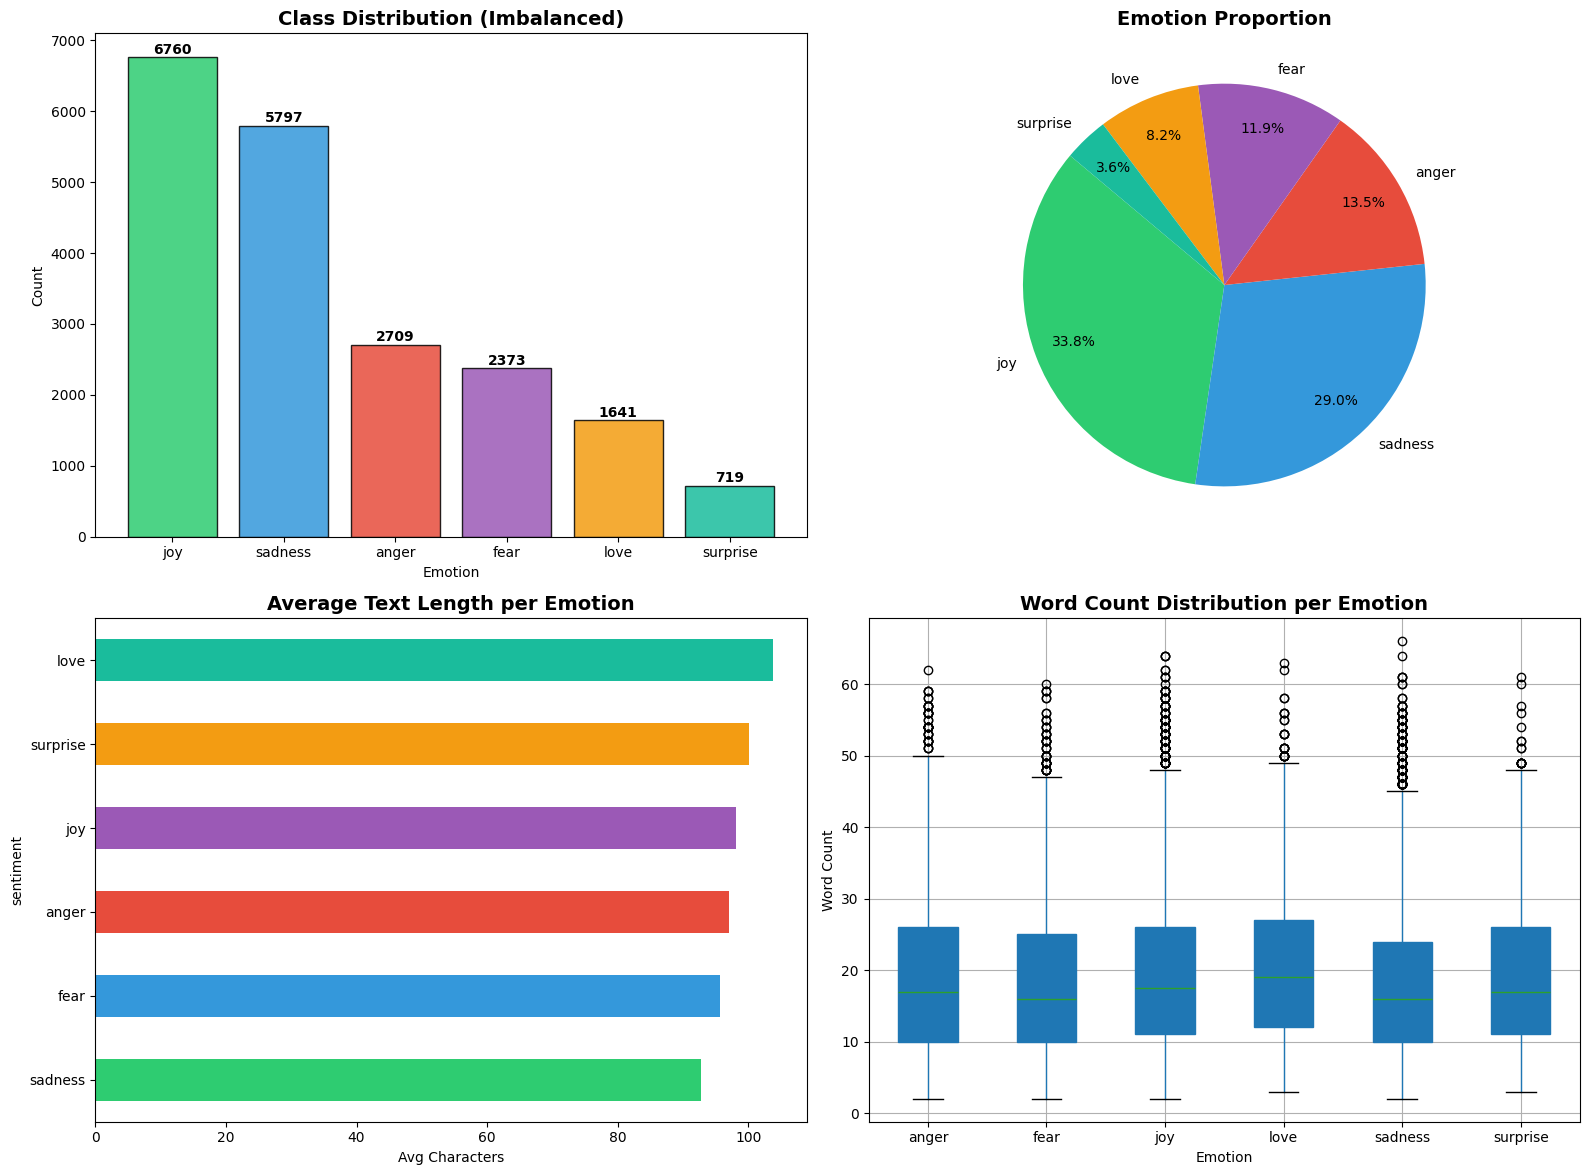

✅ EDA plots saved.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Class distribution bar chart
colors = ['#2ecc71','#3498db','#e74c3c','#9b59b6','#f39c12','#1abc9c']
dist = df['sentiment'].value_counts()
axes[0,0].bar(dist.index, dist.values, color=colors, edgecolor='black', alpha=0.85)
axes[0,0].set_title('Class Distribution (Imbalanced)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Emotion')
axes[0,0].set_ylabel('Count')
for i, (k, v) in enumerate(zip(dist.index, dist.values)):
    axes[0,0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 2. Pie chart
axes[0,1].pie(dist.values, labels=dist.index, autopct='%1.1f%%', colors=colors,
              startangle=140, pctdistance=0.8)
axes[0,1].set_title('Emotion Proportion', fontsize=14, fontweight='bold')

# 3. Text length distribution
df.groupby('sentiment')['text_len'].mean().sort_values().plot(kind='barh', ax=axes[1,0], color=colors)
axes[1,0].set_title('Average Text Length per Emotion', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Avg Characters')

# 4. Word count box plot
df.boxplot(column='word_count', by='sentiment', ax=axes[1,1], patch_artist=True)
axes[1,1].set_title('Word Count Distribution per Emotion', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Emotion')
axes[1,1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig('/content/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved.")

## h. Preprocessing Pipeline

Preprocessing steps applied:
1. **Lowercasing** – normalize text
2. **Punctuation Removal** – remove special characters
3. **Tokenization** – split text into tokens
4. **Stopword Removal** – remove common non-informative words (extended list)
5. **Lemmatization** – reduce words to base form using WordNetLemmatizer

In [ ]:
wn = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
stop_words.update(['yr','year','woman','man','girl','boy','one','two','u','n','feel','feeling','im'])

def remove_punct(text):
    return re.sub(r'[^\w\s]', '', text.lower())

def tokenize(text):
    return re.split('\W+', text)

def remove_stopwords(tokens):
    return [w for w in tokens if w not in stop_words and len(w) > 1]

def lemmatize(tokens):
    return [wn.lemmatize(w) for w in tokens]

def full_preprocess(text):
    text = remove_punct(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize(tokens)
    return ' '.join(tokens)

# Apply pipeline
df['cleaned'] = df['content'].apply(full_preprocess)

# Show sample
print("── Preprocessing Samples ──")
for i in [0, 1, 2]:
    print(f"\nOriginal : {df['content'].iloc[i]}")
    print(f"Cleaned  : {df['cleaned'].iloc[i]}")
    print(f"Emotion  : {df['sentiment'].iloc[i]}")

── Preprocessing Samples ──

Original : i didnt feel humiliated
Cleaned  : didnt humiliated
Emotion  : sadness

Original : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Cleaned  : go hopeless damned hopeful around someone care awake
Emotion  : sadness

Original : im grabbing a minute to post i feel greedy wrong
Cleaned  : grabbing minute post greedy wrong
Emotion  : anger


## i. Word Cloud per Emotion

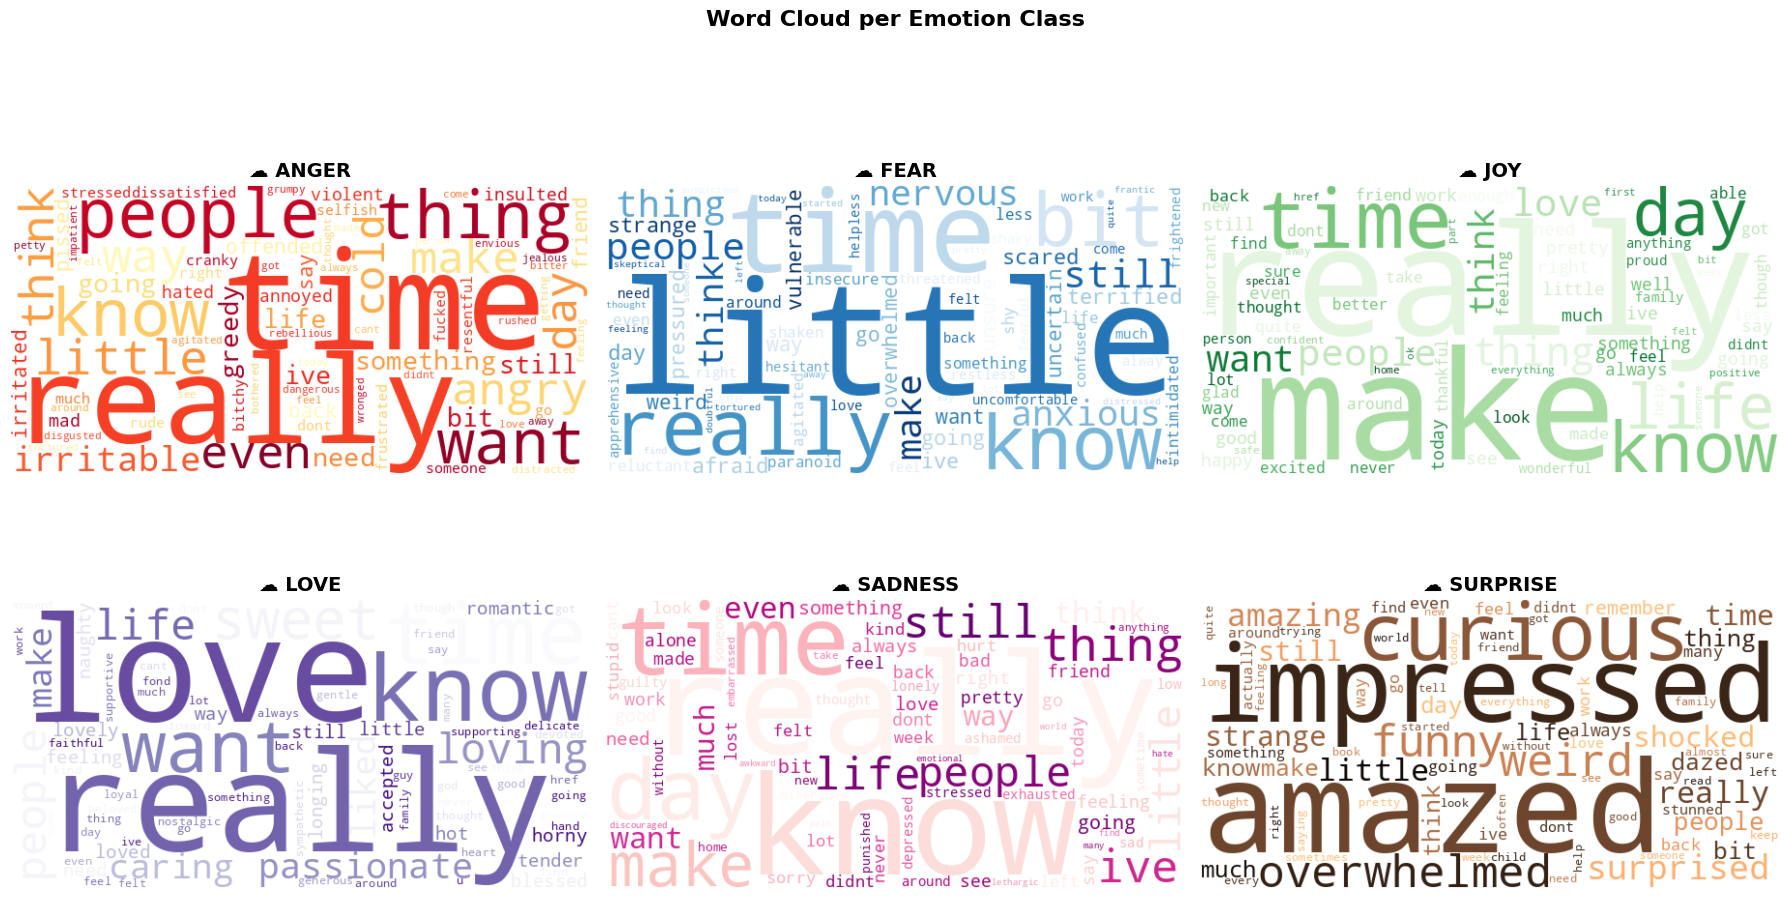

✅ Word clouds generated.


In [ ]:
if WC_AVAILABLE:
    emotions = df['sentiment'].unique()
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    color_maps = ['YlOrRd', 'Blues', 'Greens', 'Purples', 'RdPu', 'copper']

    for idx, emotion in enumerate(sorted(emotions)):
        text = ' '.join(df[df['sentiment'] == emotion]['cleaned'])
        wc = WordCloud(width=600, height=300, background_color='white',
                       colormap=color_maps[idx], max_words=80).generate(text)
        axes[idx].imshow(wc, interpolation='bilinear')
        axes[idx].set_title(f'☁ {emotion.upper()}', fontsize=14, fontweight='bold')
        axes[idx].axis('off')

    plt.suptitle('Word Cloud per Emotion Class', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('/content/wordclouds.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Word clouds generated.")
else:
    print("WordCloud library not available. Install with: pip install wordcloud")

In [ ]:
# ── TF-IDF Feature Extraction ──
X = df['cleaned']
y = df['sentiment']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_
print("Classes:", classes)

# Dataset split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nDataset Split:")
print(f"  Train : {len(X_train):5d} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val   : {len(X_val):5d} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test  : {len(X_test):5d} ({len(X_test)/len(X)*100:.1f}%)")

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nTF-IDF Feature Matrix Shape (train): {X_train_tfidf.shape}")
print(f"Vocabulary Size: {len(tfidf.vocabulary_)}")

Classes: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']

Dataset Split:
  Train : 13999 (70.0%)
  Val   :  3000 (15.0%)
  Test  :  3000 (15.0%)

TF-IDF Feature Matrix Shape (train): (13999, 20000)
Vocabulary Size: 20000


## j. Dataset Imbalance Mitigation — SMOTE

The dataset is **imbalanced** (joy: 6761, surprise: 719 — ratio 9.4x).
We apply **SMOTE (Synthetic Minority Over-sampling Technique)** on the TF-IDF features.

**How SMOTE works:**
For each minority sample, SMOTE finds k nearest neighbors and generates synthetic samples
along the line segments joining those neighbors:

$$x_{new} = x_i + \lambda \cdot (x_{zi} - x_i), \quad \lambda \in [0, 1]$$

Where $x_{zi}$ is a randomly chosen neighbor of $x_i$.

Before SMOTE: Counter({'joy': 4732, 'sadness': 4058, 'anger': 1896, 'fear': 1661, 'love': 1149, 'surprise': 503})
After SMOTE : Counter({'joy': 4732, 'fear': 4732, 'sadness': 4732, 'anger': 4732, 'surprise': 4732, 'love': 4732})


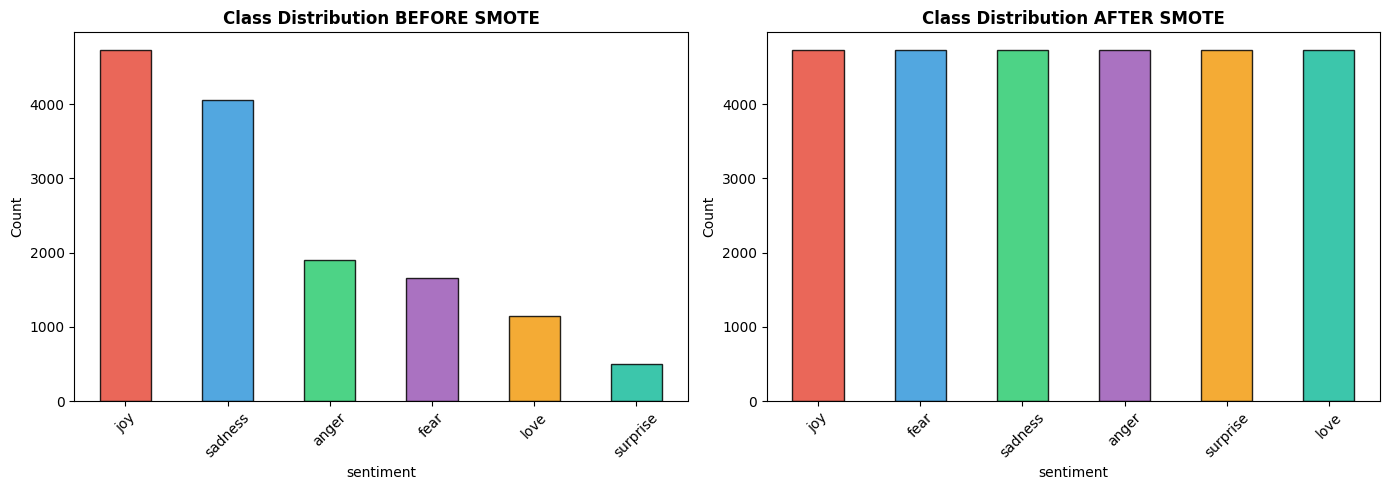

✅ SMOTE applied successfully.


In [ ]:
from collections import Counter

print("Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)

print("After SMOTE :", Counter(y_train_sm))

# Plot before/after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
before = pd.Series(y_train).value_counts()
after  = pd.Series(y_train_sm).value_counts()
colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12','#1abc9c']

before.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution BEFORE SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

after.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Class Distribution AFTER SMOTE', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SMOTE applied successfully.")

## n. Hyperparameter Setup

| Model | Parameter | Value | Description |
|-------|-----------|-------|-------------|
| SVM (SGD) | loss | 'hinge' | SVM loss function |
| SVM (SGD) | max_iter | 1000 | Max iterations |
| SVM (SGD) | random_state | 42 | Reproducibility |
| Logistic Regression | C | 1.0 | Regularization strength |
| Logistic Regression | max_iter | 1000 | Convergence limit |
| Logistic Regression | solver | 'lbfgs' | Optimization algorithm |
| Random Forest | n_estimators | 100 | Number of trees |
| Random Forest | max_depth | None | Unlimited tree depth |
| Random Forest | random_state | 42 | Reproducibility |
| XGBoost | n_estimators | 200 | Boosting rounds |
| XGBoost | max_depth | 6 | Tree depth |
| XGBoost | learning_rate | 0.1 | Step size shrinkage |
| Naive Bayes | alpha | 1.0 | Laplace smoothing |
| Decision Tree | max_depth | 20 | Tree depth limit |
| Decision Tree | random_state | 42 | Reproducibility |
| TF-IDF | max_features | 20000 | Vocabulary cap |
| TF-IDF | ngram_range | (1,2) | Unigrams + bigrams |
| SMOTE | k_neighbors | 5 | Default neighbors |

## l. Model Training & Implementation

In [ ]:
 import time

# Helper to evaluate a model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    y_pred = model.predict(X_te)

    # Determine labels for confusion matrix based on the type of y_te
    # If y_te is numeric (e.g., integers from LabelEncoder), use integer labels
    # Otherwise (e.g., strings), use the original class names
    if pd.api.types.is_numeric_dtype(y_te):
        cm_labels_arg = np.arange(len(classes))
    else:
        cm_labels_arg = classes

    acc   = accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, average='macro', zero_division=0)
    rec   = recall_score(y_te, y_pred, average='macro', zero_division=0)
    f1    = f1_score(y_te, y_pred, average='macro', zero_division=0)
    cm    = confusion_matrix(y_te, y_pred, labels=cm_labels_arg)
    return {'name': name, 'model': model, 'y_pred': y_pred,
            'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1,
            'cm': cm, 'train_time': train_time}

# Define models with hyperparameters
models_def = [
    ('SVM',              SGDClassifier(loss='hinge', max_iter=1000, random_state=42)),
    ('Logistic Reg',     LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', multi_class='multinomial', random_state=42)),
    ('Random Forest',    RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGBoost',          XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                        use_label_encoder=False, eval_metric='mlogloss',
                                        random_state=42, verbosity=0)),
    ('Naive Bayes',      MultinomialNB(alpha=1.0)),
    ('Decision Tree',    tree.DecisionTreeClassifier(max_depth=20, random_state=42)),
]

results = []
y_train_enc = le.transform(y_train_sm)
y_test_enc  = le.transform(y_test)

print(f"{'Model':<20} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Time(s)':>9}")
print("-" * 70)

for name, m in models_def:
    if name == 'XGBoost':
        r = evaluate_model(name, m, X_train_sm, y_train_enc, X_test_tfidf, y_test_enc)
        r['y_pred_str'] = le.inverse_transform(r['y_pred'])
        # Recalculate CM with original string labels for consistent display later
        r['cm'] = confusion_matrix(y_test, r['y_pred_str'], labels=classes)
    else:
        r = evaluate_model(name, m, X_train_sm, y_train_sm, X_test_tfidf, y_test)
    results.append(r)
    print(f"{name:<20} {r['acc']:>9.4f} {r['prec']:>10.4f} {r['rec']:>8.4f} {r['f1']:>8.4f} {r['train_time']:>9.2f}")

Model                 Accuracy  Precision   Recall       F1   Time(s)
----------------------------------------------------------------------
SVM                     0.8890     0.8400   0.8962   0.8620      0.37
Logistic Reg            0.8780     0.8359   0.8611   0.8462      8.16
Random Forest           0.8770     0.8433   0.8679   0.8541     94.85
XGBoost                 0.8740     0.8271   0.8836   0.8492    214.86
Naive Bayes             0.8207     0.7597   0.8069   0.7787      0.08
Decision Tree           0.1950     0.4103   0.3567   0.2550      1.91


## f. Confusion Matrices for All Models

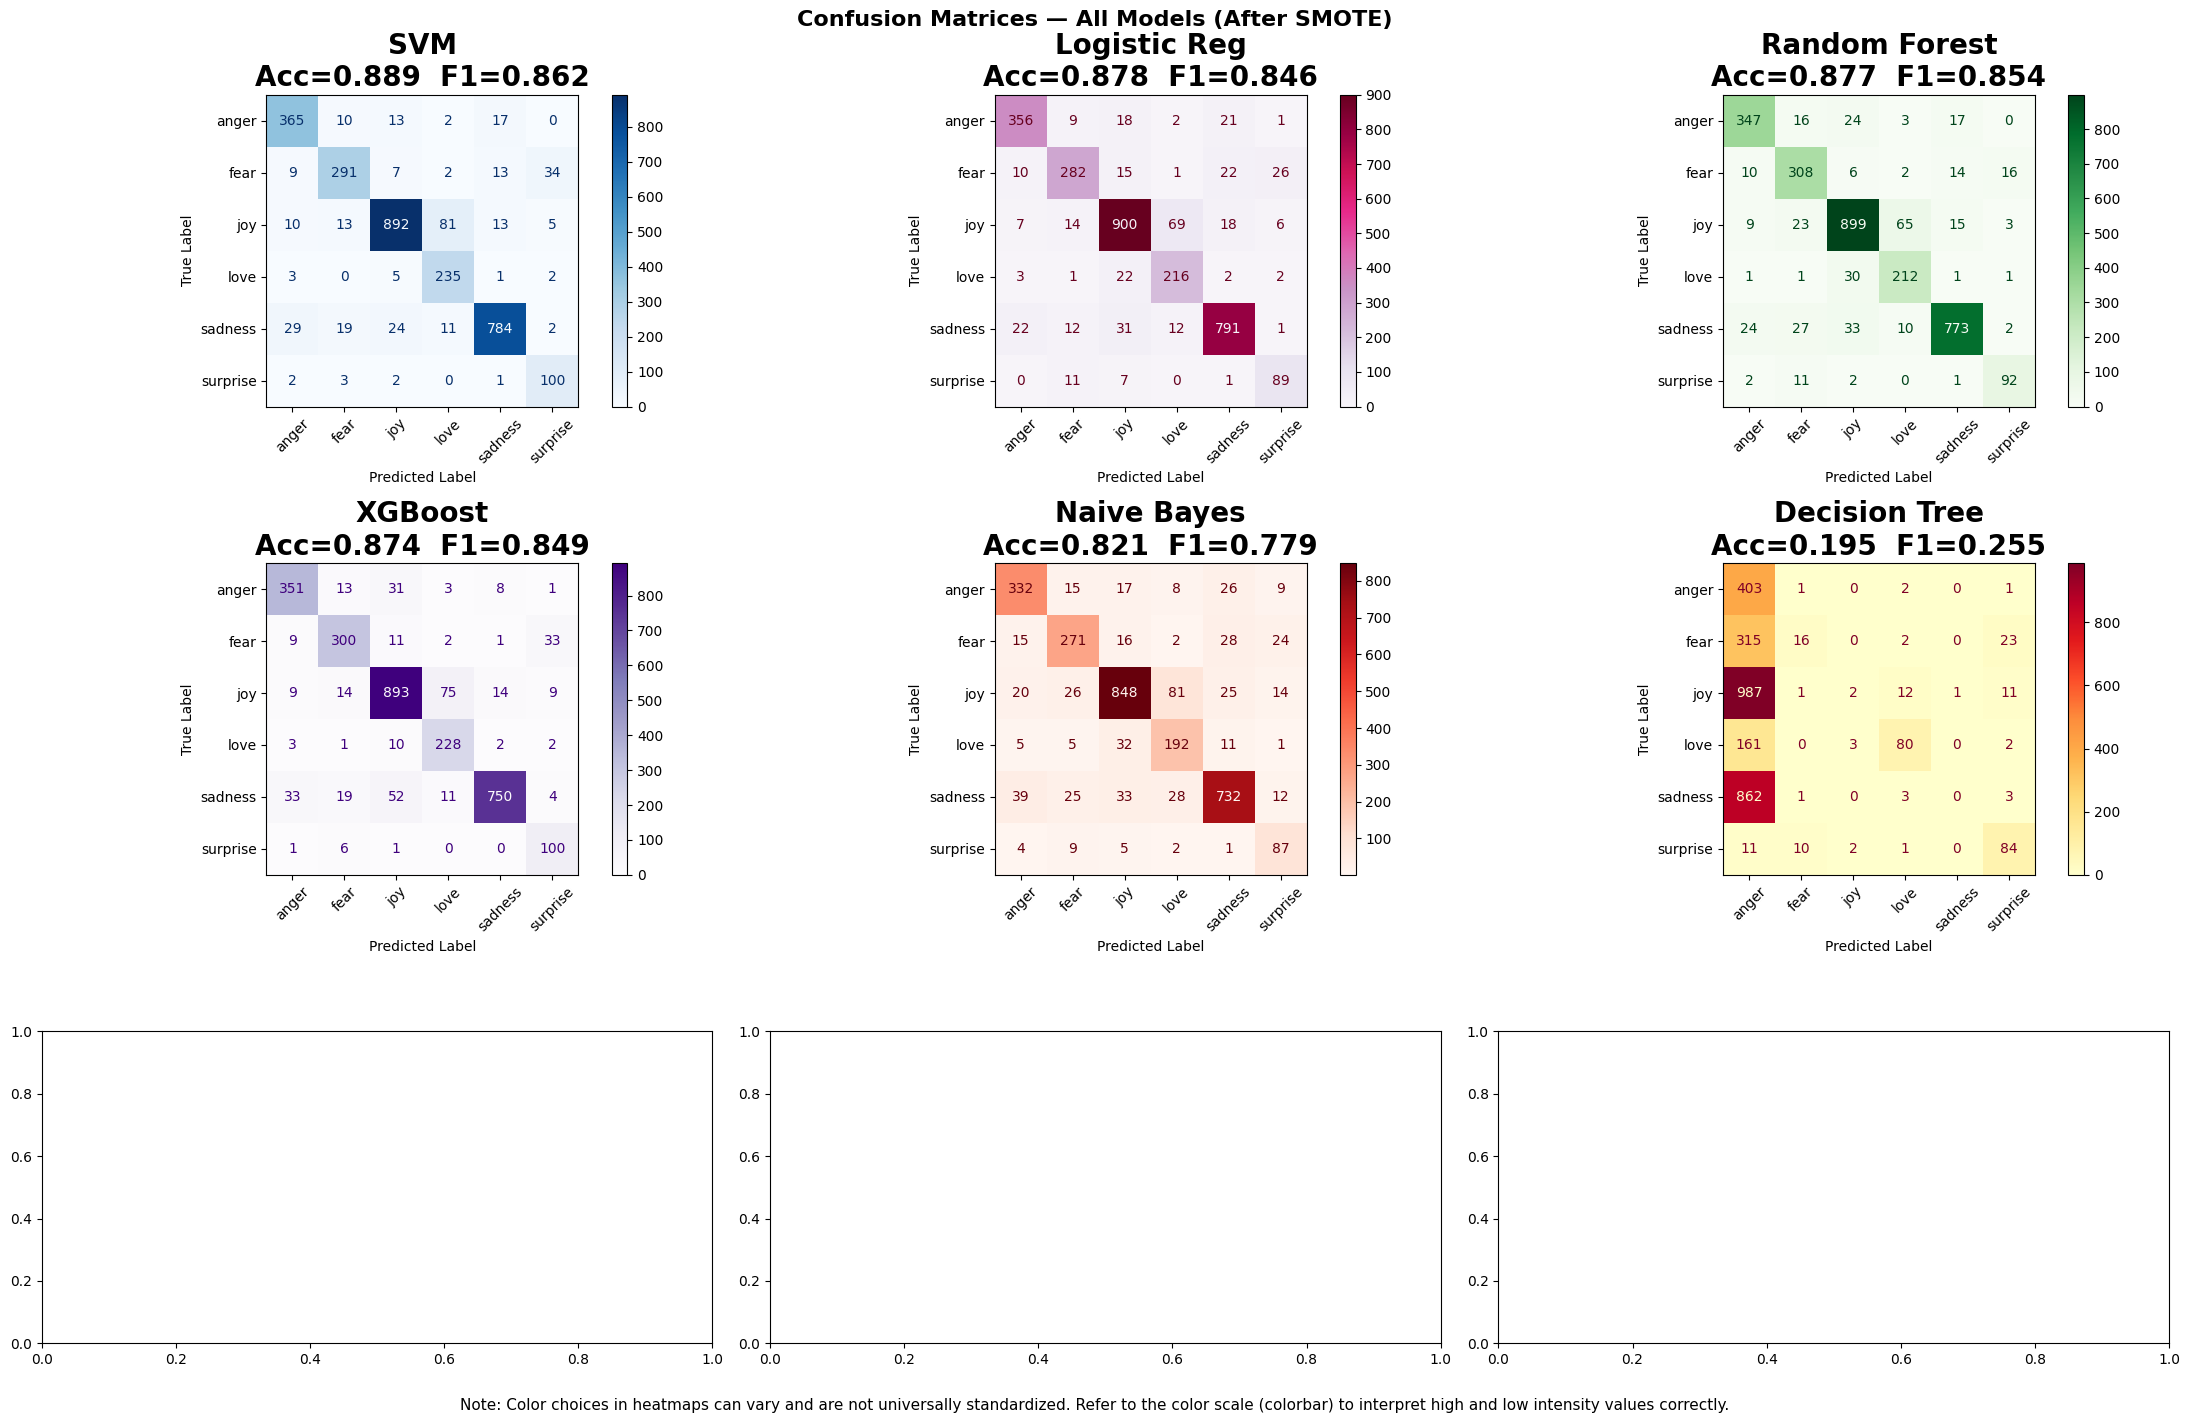

✅ All confusion matrices saved with clean axes.


In [ ]:
cmaps = ['Blues','PuRd','Greens','Purples','Reds','YlOrRd']

fig, axes = plt.subplots(3, 3, figsize=(22, 14))
axes = axes.flatten()

for idx, r in enumerate(results):
    disp = ConfusionMatrixDisplay(r['cm'], display_labels=classes)
    disp.plot(ax=axes[idx], cmap=cmaps[idx], colorbar=True)

    # Title
    axes[idx].set_title(
        f"{r['name']}\nAcc={r['acc']:.3f}  F1={r['f1']:.3f}",
        fontsize=20, fontweight='bold'
    )

    # ✅ Make axis consistent
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

    # Rotate x labels
    axes[idx].tick_params(axis='x', rotation=45)

# Main title
plt.suptitle('Confusion Matrices — All Models (After SMOTE)',
             fontsize=16, fontweight='bold')

# ✅ Add note
plt.figtext(
    0.5, -0.02,
    "Note: Color choices in heatmaps can vary and are not universally standardized. "
    "Refer to the color scale (colorbar) to interpret high and low intensity values correctly.",
    wrap=True,
    horizontalalignment='center',
    fontsize=11
)

plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ All confusion matrices saved with clean axes.")

## e & h. Classification Reports & Performance Metrics

**Metric Formulas:**
- $Precision = \frac{TP}{TP+FP}$
- $Recall = \frac{TP}{TP+FN}$
- $F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$
- $Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$

In [ ]:
# Best model classification report
best = max(results, key=lambda r: r['f1'])
print(f"\n── Best Model: {best['name']} (F1={best['f1']:.4f}) ──\n")
y_pred_best = best.get('y_pred_str', best['y_pred'])
print(classification_report(y_test, y_pred_best, target_names=classes))


── Best Model: SVM (F1=0.8620) ──

              precision    recall  f1-score   support

       anger       0.87      0.90      0.88       407
        fear       0.87      0.82      0.84       356
         joy       0.95      0.88      0.91      1014
        love       0.71      0.96      0.81       246
     sadness       0.95      0.90      0.92       869
    surprise       0.70      0.93      0.80       108

    accuracy                           0.89      3000
   macro avg       0.84      0.90      0.86      3000
weighted avg       0.90      0.89      0.89      3000



## f. ROC-AUC Curves (One-vs-Rest)

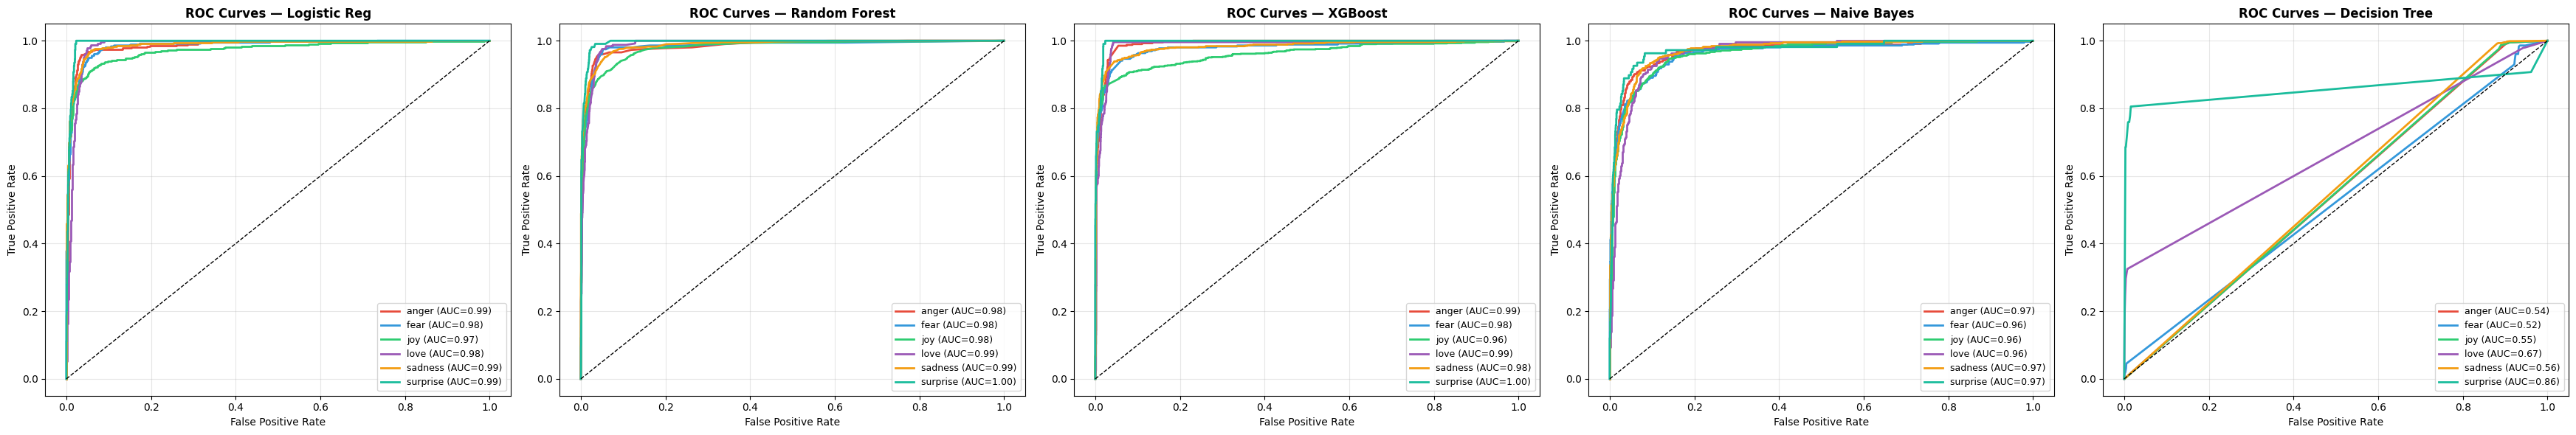

✅ ROC-AUC curves saved.


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Use best model that has predict_proba
proba_models = [r for r in results if hasattr(r['model'], 'predict_proba')]
if not proba_models:
    print("No model with predict_proba available.")
else:
    fig, axes = plt.subplots(1, len(proba_models), figsize=(7*len(proba_models), 6))
    if len(proba_models) == 1:
        axes = [axes]
    y_bin = label_binarize(y_test, classes=classes)
    colors_roc = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12','#1abc9c']

    for ax, r in zip(axes, proba_models):
        y_score = r['model'].predict_proba(X_test_tfidf)
        for i, (cls, c) in enumerate(zip(classes, colors_roc)):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=c, lw=2, label=f'{cls} (AUC={roc_auc:.2f})')
        ax.plot([0,1],[0,1],'k--', lw=1)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC Curves — {r["name"]}', fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ ROC-AUC curves saved.")

## i & j. Model Comparison — Tabular & Graphical

── Model Comparison Table ──
        Model  Accuracy  Precision  Recall  F1-Score  Train Time(s)
          SVM    0.8890     0.8400  0.8962    0.8620           0.37
Random Forest    0.8770     0.8433  0.8679    0.8541          94.85
      XGBoost    0.8740     0.8271  0.8836    0.8492         214.86
 Logistic Reg    0.8780     0.8359  0.8611    0.8462           8.16
  Naive Bayes    0.8207     0.7597  0.8069    0.7787           0.08
Decision Tree    0.1950     0.4103  0.3567    0.2550           1.91


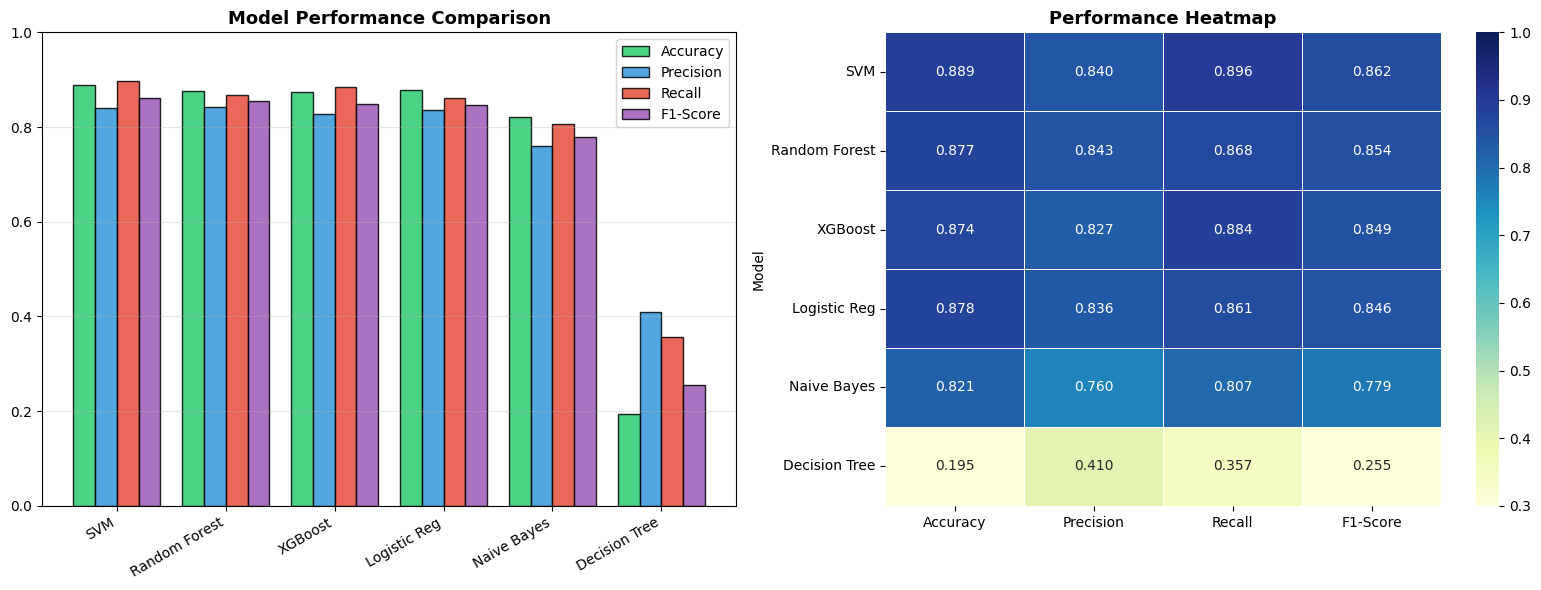

In [ ]:
results_df = pd.DataFrame([
    {
    'Model': r['name'], 'Accuracy': round(r['acc'],4),
    'Precision': round(r['prec'],4), 'Recall': round(r['rec'],4),
    'F1-Score': round(r['f1'],4), 'Train Time(s)': round(r['train_time'],2)
} for r in results]).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("── Model Comparison Table ──")
print(results_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics = ['Accuracy','Precision','Recall','F1-Score']
x = np.arange(len(results_df))
width = 0.2
colors_m = ['#2ecc71','#3498db','#e74c3c','#9b59b6']

for i, (metric, c) in enumerate(zip(metrics, colors_m)):
    axes[0].bar(x + i*width, results_df[metric], width, label=metric, color=c, alpha=0.85, edgecolor='black')

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(results_df['Model'], rotation=30, ha='right')
axes[0].set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
axes[0].legend()
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# Heatmap
heatmap_data = results_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score']]
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGnBu',
            ax=axes[1], linewidths=0.5, vmin=0.3, vmax=1.0)
axes[1].set_title('Performance Heatmap', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

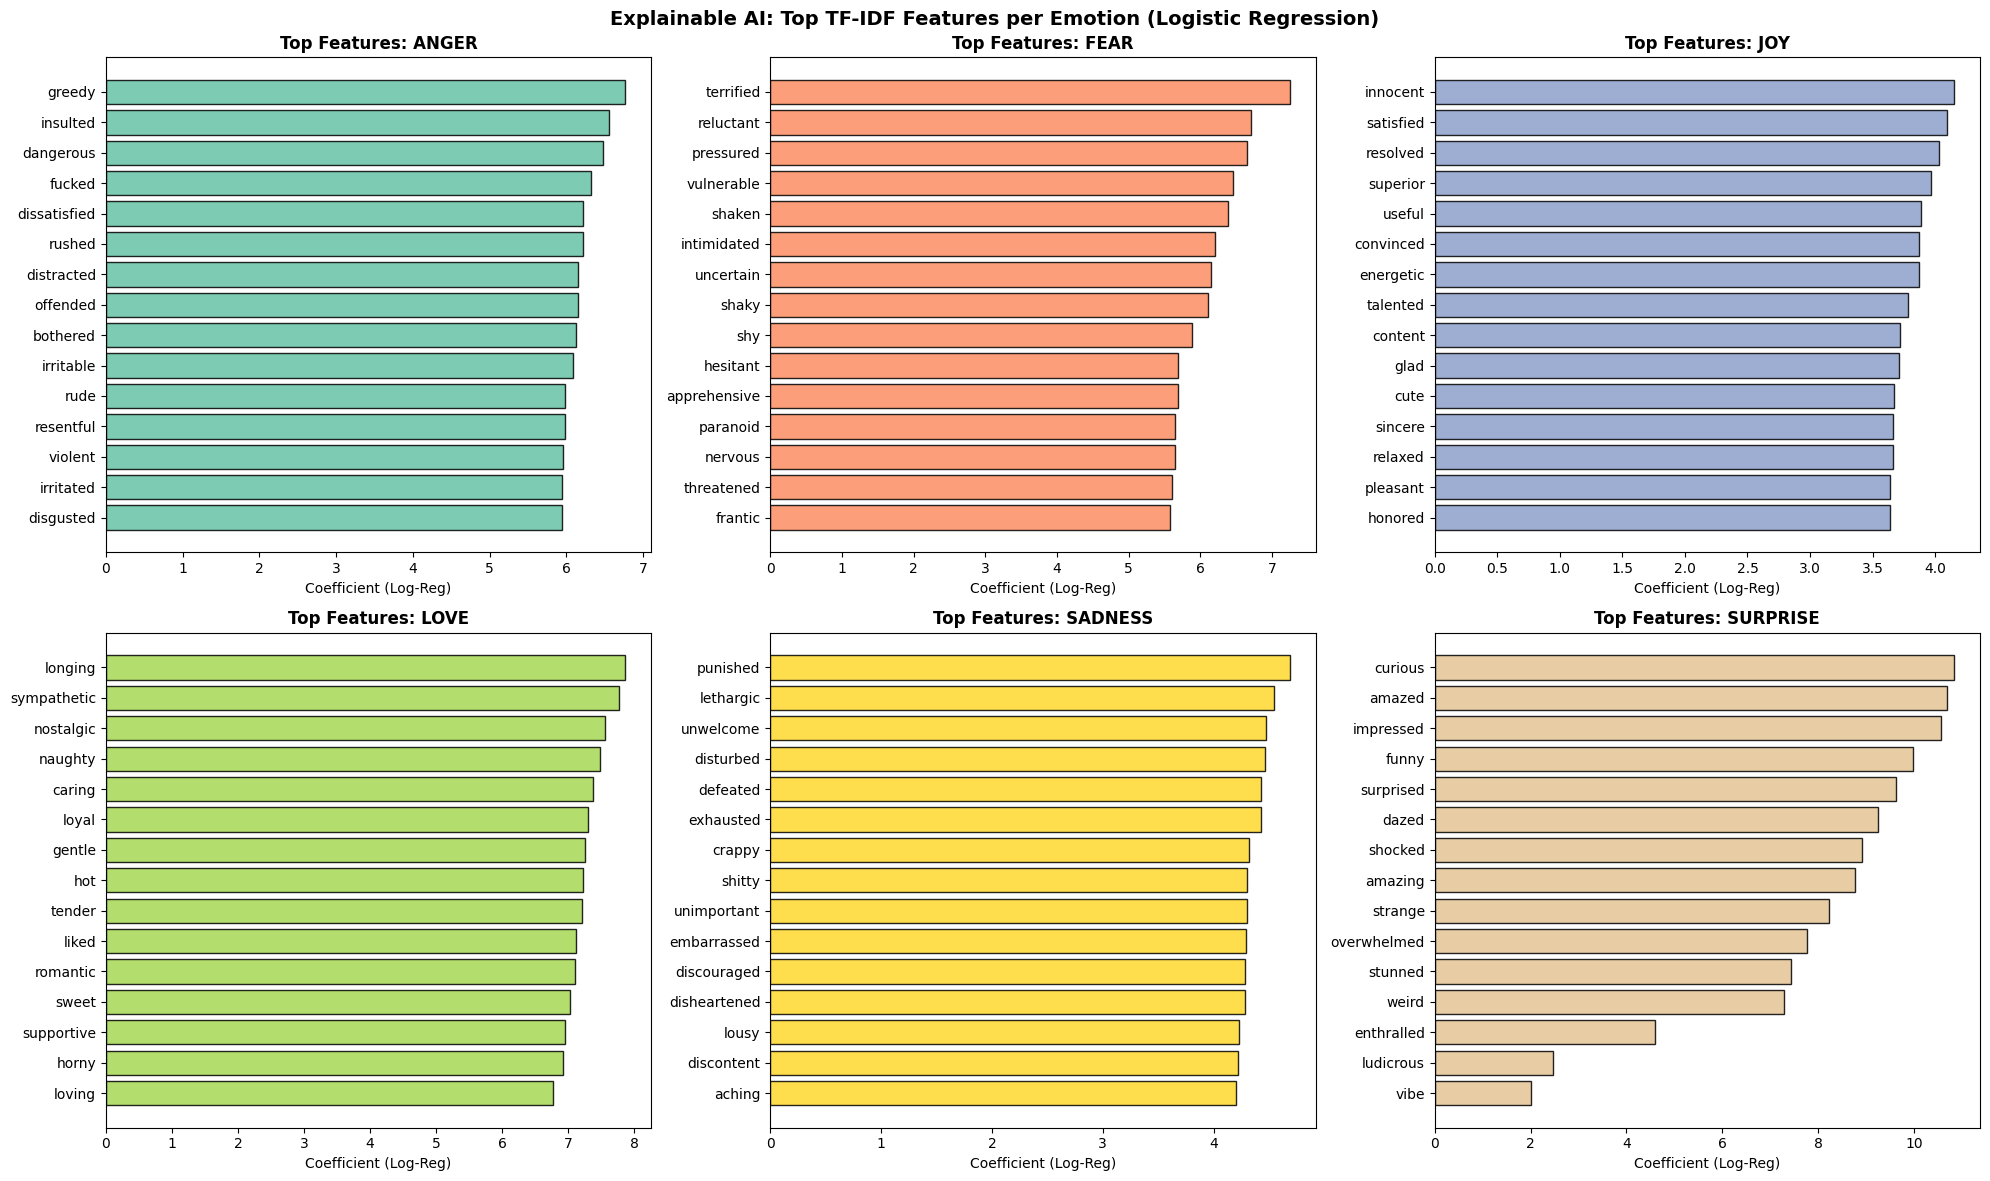


✅ Feature importance reveals key words driving each emotion prediction.
   This is an Explainability technique — showing model behavior via coefficients.


In [ ]:
# ── TF-IDF Feature Importance (Top words per emotion) ──
lr_model = next(r['model'] for r in results if r['name'] == 'Logistic Reg')
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, (cls, coef) in enumerate(zip(lr_model.classes_, lr_model.coef_)):
    top_idx = np.argsort(coef)[-15:]
    top_feats = feature_names[top_idx]
    top_coefs = coef[top_idx]
    color = plt.cm.Set2(idx / len(lr_model.classes_))
    axes[idx].barh(top_feats, top_coefs, color=color, edgecolor='black', alpha=0.85)
    axes[idx].set_title(f'Top Features: {cls.upper()}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Coefficient (Log-Reg)')

plt.suptitle('Explainable AI: Top TF-IDF Features per Emotion (Logistic Regression)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Feature importance reveals key words driving each emotion prediction.")
print("   This is an Explainability technique — showing model behavior via coefficients.")

## k. Applications

This emotion detection system has wide real-world applications:

| Domain | Application |
|--------|-------------|
| **Mental Health** | Detect depression/anxiety signals in social media posts |
| **Customer Service** | Auto-tag customer complaints by emotional tone (anger, fear) |
| **E-Commerce** | Analyze product reviews for emotional sentiment |
| **Education** | Monitor student feedback and engagement levels |
| **HR & Workplace** | Employee sentiment analysis from internal communications |
| **Healthcare** | Patient feedback emotion analysis for care improvement |
| **Social Media** | Real-time crisis detection (fear, sadness spikes) |
| **Content Moderation** | Flag emotionally charged harmful content |
| **Voice Assistants** | Improve response by detecting user frustration |
| **News & Media** | Emotion-aware content recommendation |

## p. Pseudo-code / Implementation Steps

```
ALGORITHM: Text Emotion Classification Pipeline

INPUT:  Raw text dataset (content, sentiment)
OUTPUT: Predicted emotion labels + evaluation metrics

BEGIN
  1. LOAD dataset from CSV
  2. COMPUTE descriptive statistics (shape, class distribution, text length)
  3. EDA:
       a. Plot class distribution (bar, pie)
       b. Plot text length distributions
       c. Generate word clouds per emotion

  4. PREPROCESSING:
     FOR EACH text IN dataset:
       a. Lowercase text
       b. Remove punctuation using regex
       c. Tokenize by splitting on non-word chars
       d. Remove stopwords using NLTK corpus
       e. Lemmatize tokens using WordNetLemmatizer
       f. Join tokens back to string

  5. FEATURE EXTRACTION:
     a. Split data → Train(70%), Val(15%), Test(15%) [stratified]
     b. Fit TF-IDF Vectorizer on Train (max_features=20000, ngram_range=(1,2))
     c. Transform Val and Test using fitted vectorizer

  6. IMBALANCE MITIGATION:
     a. Apply SMOTE on (X_train_tfidf, y_train)
     b. Verify balanced class counts after resampling

  7. MODEL TRAINING:
     FOR EACH model IN [SVM, LR, RF, XGBoost, NB, DT]:
       a. fit(X_train_SMOTE, y_train_SMOTE)
       b. predict(X_test_tfidf)
       c. Compute: Accuracy, Precision, Recall, F1
       d. Build confusion matrix

  8. EVALUATION:
     a. Plot confusion matrices for all models
     b. Plot ROC-AUC curves (one-vs-rest)
     c. Print classification reports
     d. Compare models in table and heatmap

  9. EXPLAINABILITY:
     a. LIME: perturb sample → local linear approx → top features
     b. Logistic Regression coefficients → top words per class

  10. COMPARISON:
     a. Tabulate all results
     b. Identify best model by F1-Score
     c. List pros/cons per model

END
```

## Summary & Final Results

In [ ]:
print("=" * 60)
print("  FINAL PROJECT SUMMARY — Emotion Detection NLP")
print("=" * 60)
print(f"  Dataset         : text_emotions.csv (20,000 samples)")
print(f"  Language        : English")
print(f"  Emotions        : {', '.join(classes)}")
print(f"  Imbalance Fix   : SMOTE")
print(f"  Feature Extractor: TF-IDF (20k features, bigrams)")
print(f"  Train/Val/Test  : 70% / 15% / 15%")
print()
print(f"{'Model':<22} {'Accuracy':>9} {'F1-Score':>9}")
print("-" * 45)
for _, row in results_df.iterrows():
    marker = " ← BEST" if row['F1-Score'] == results_df['F1-Score'].max() else ""
    print(f"  {row['Model']:<20} {row['Accuracy']:>9.4f} {row['F1-Score']:>9.4f}{marker}")
print("=" * 60)

  FINAL PROJECT SUMMARY — Emotion Detection NLP
  Dataset         : text_emotions.csv (20,000 samples)
  Language        : English
  Emotions        : anger, fear, joy, love, sadness, surprise
  Imbalance Fix   : SMOTE
  Feature Extractor: TF-IDF (20k features, bigrams)
  Train/Val/Test  : 70% / 15% / 15%

Model                   Accuracy  F1-Score
---------------------------------------------
  SVM                     0.8890    0.8620 ← BEST
  Random Forest           0.8770    0.8541
  XGBoost                 0.8740    0.8492
  Logistic Reg            0.8780    0.8462
  Naive Bayes             0.8207    0.7787
  Decision Tree           0.1950    0.2550


---
## 🎙️ Speech-to-Emotion Pipeline (Whisper ASR + Saved Models)



In [ ]:
# ── Install Required Packages ──
# Run this once if not already installed
!pip install transformers librosa soundfile torch --quiet

In [ ]:
import os, pickle

os.makedirs('saved_models', exist_ok=True)

# Save the TF-IDF vectorizer (fitted on training data)
with open('saved_models/count_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)          # tfidf = TfidfVectorizer from training section

# Save best model — find it from results list
best_model = max(results, key=lambda r: r['f1'])
print(f"💾 Saving best model: {best_model['name']} (F1={best_model['f1']:.4f})")

with open('saved_models/svm.pkl', 'wb') as f:
    pickle.dump(best_model['model'], f)

# Also save label encoder
with open('saved_models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ Models saved to saved_models/")
print("   ├── count_vectorizer.pkl  (TF-IDF vectorizer)")
print("   ├── svm.pkl               (Best classifier)")
print("   └── label_encoder.pkl     (Label encoder)")

💾 Saving best model: SVM (F1=0.8620)
✅ Models saved to saved_models/
   ├── count_vectorizer.pkl  (TF-IDF vectorizer)
   ├── svm.pkl               (Best classifier)
   └── label_encoder.pkl     (Label encoder)


In [ ]:
import pickle
import warnings
warnings.filterwarnings("ignore")

import torch
import librosa
import soundfile as sf
import numpy as np
import re, string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from transformers import pipeline

# ─────────────────────────────────────────────────────────────
# 1. Load Saved Models
# ─────────────────────────────────────────────────────────────
try:
    with open('saved_models/count_vectorizer.pkl', 'rb') as f:
        countVectorizer = pickle.load(f)

    with open('saved_models/svm.pkl', 'rb') as f:
        model = pickle.load(f)

    with open('saved_models/label_encoder.pkl', 'rb') as f:
        label_enc = pickle.load(f)

    print("✅ All models loaded successfully!")

except FileNotFoundError as e:
    print(f"❌ Model file not found: {e}")
    print("   ► Run the 'Save Trained Models' cell above first!")
    raise

# ─────────────────────────────────────────────────────────────
# 2. Load Whisper ASR
# ─────────────────────────────────────────────────────────────
print("\n⏳ Loading Whisper model...")
asr = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-small",
    chunk_length_s=30,          # ← Fix for num_frames error on short/long audio
    device=0 if torch.cuda.is_available() else -1,
)
print(f"✅ Whisper loaded | Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

# ─────────────────────────────────────────────────────────────
# 3. Preprocessing (matches training pipeline exactly)
# ─────────────────────────────────────────────────────────────
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

stopword = set(stopwords.words('english'))
stopword.update([
    'yr','year','woman','man','girl','boy','one','two','sixteen','yearold',
    'fu','weeks','week','treatment','associated','patients','may','day',
    'case','old','u','n','didnt','ive','ate','feel','keep','brother',
    'dad','basic','im'
])

wn = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\@\w+|\#', '', text)
    text = "".join([c for c in text if c not in string.punctuation])
    text = re.sub(r'[0-9]+', '', text)
    tokens = re.split(r'\W+', text)
    tokens = [w for w in tokens if w and w not in stopword]
    tokens = [wn.lemmatize(w) for w in tokens]
    return " ".join(tokens)

print("✅ Preprocessing pipeline ready.")

# ─────────────────────────────────────────────────────────────
# 4. Speech → Emotion Pipeline
# ─────────────────────────────────────────────────────────────
EMOTION_EMOJI = {
    'joy': '😄', 'sadness': '😢', 'anger': '😠',
    'fear': '😨', 'love': '❤️',  'surprise': '😲'
}

def speech_to_emotion(audio_path):
    """
    Transcribes audio with Whisper and predicts emotion.
    Parameters:
        audio_path (str): Path to .wav / .mp3 file
    Returns:
        (transcribed_text, predicted_emotion) or (None, None) on error
    """
    print(f"\n{'='*60}")
    print(f"🔊 Processing: {audio_path}")
    print('='*60)

    try:
        # Step 1 — Load & resample to 16 kHz mono numpy array
        audio_array, sr = librosa.load(audio_path, sr=16000, mono=True)
        duration = len(audio_array) / 16000
        print(f"   ✔ Audio loaded | Duration: {duration:.2f}s | SR: 16kHz")

        # Step 2 — Whisper ASR  (pass numpy array directly — avoids num_frames bug)
        print("🎤 Transcribing with Whisper...")
        result = asr(
            {"array": audio_array, "sampling_rate": 16000},
            generate_kwargs={"language": "english", "task": "transcribe"}
        )
        transcribed_text = result["text"].strip()
        print(f"   ✔ Transcription: \"{transcribed_text}\"")

        # Step 3 — Clean text
        cleaned = clean_text(transcribed_text)
        print(f"   ✔ Cleaned text : \"{cleaned}\"")

        if not cleaned:
            print("⚠️  Warning: cleaned text is empty — audio may be silent or unclear.")
            return transcribed_text, "unknown"

        # Step 4 — TF-IDF features
        tfidf_vec = countVectorizer.transform([cleaned])

        # Step 5 — Predict
        predicted_emotion = model.predict(tfidf_vec)[0]

        # Confidence scores (if model supports it)
        proba = None
        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(tfidf_vec)[0]
            class_names = model.classes_
        elif hasattr(model, 'decision_function'):
            # SGD/SVM → convert decision scores to pseudo-probabilities
            scores = model.decision_function(tfidf_vec)[0]
            exp_s = np.exp(scores - scores.max())
            proba = exp_s / exp_s.sum()
            class_names = model.classes_

        # ── Final Output ──
        emoji = EMOTION_EMOJI.get(predicted_emotion, '🤔')
        print(f"\n{emoji}  Predicted Emotion: {predicted_emotion.upper()}")

        if proba is not None:
            print("\n📊 Confidence Scores:")
            for cls, p in sorted(zip(class_names, proba), key=lambda x: -x[1]):
                bar = '█' * int(p * 40)
                mark = ' ◄' if cls == predicted_emotion else ''
                print(f"   {EMOTION_EMOJI.get(cls,'  ')} {cls:<10} {p*100:5.1f}%  {bar}{mark}")

        return transcribed_text, predicted_emotion

    except FileNotFoundError:
        print(f"❌ Audio file not found: {audio_path}")
        print("   ► Upload your file to /content/ and update the path below.")
        return None, None
    except Exception as e:
        print(f"❌ Unexpected error: {type(e).__name__}: {e}")
        return None, None

# ─────────────────────────────────────────────────────────────
# 5. Run  ← update filename here
# ─────────────────────────────────────────────────────────────
transcribed_text, predicted_emotion = speech_to_emotion("/content/piece of garbage (1).wav")

if transcribed_text and predicted_emotion:
    print("\n" + "="*60)
    print("🎤  TRANSCRIBED TEXT:")
    print(f"    {transcribed_text}")
    print(f"\n{EMOTION_EMOJI.get(predicted_emotion,'😊')}  PREDICTED EMOTION:")
    print(f"    {predicted_emotion.upper()}")
    print("="*60)

✅ All models loaded successfully!

⏳ Loading Whisper model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


✅ Whisper loaded | Device: CPU
✅ Preprocessing pipeline ready.

🔊 Processing: /content/piece of garbage (1).wav
❌ Audio file not found: /content/piece of garbage (1).wav
   ► Upload your file to /content/ and update the path below.
